In [1]:
import sys, warnings
import pandas as pd
import numpy as np
warnings.filterwarnings('ignore')
sys.path.append('../..')
import xgboost as xgb
import lightgbm as lgb
import joblib
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
from src.models.xgboost_model import train_xgboost
from src.models.lgbm_model    import train_lgbm
from src.utils.config import TICKERS
from src.models.data_loader import load_splits


def run_independent_cv(model, X_train, y_train, model_type='xgb'):
    """
    Run independent 5-fold TimeSeriesSplit CV on a trained model.
    Uses the trained model's params — no Optuna involved.
    Returns mean CV AUC.
    """
    params = model.get_params()

    # Remove conflicting params
    keys_to_remove = [
        'scale_pos_weight', 'random_state', 'verbose',
        'eval_metric', 'verbosity', 'class_weight',
        'n_jobs', 'importance_type', 'subsample_for_bin',
        'min_split_gain', 'min_child_weight', 'objective',
        'base_score', 'booster', 'callbacks',
        'early_stopping_rounds', 'enable_categorical',
        'feature_types', 'gamma', 'grow_policy',
        'interaction_constraints', 'max_bin',
        'max_cat_threshold', 'max_cat_to_onehot',
        'max_delta_step', 'max_leaves', 'missing',
        'monotone_constraints', 'num_parallel_tree',
        'sampling_method', 'tree_method',
        'validate_parameters', 'device',
    ]
    for k in keys_to_remove:
        params.pop(k, None)

    tscv = TimeSeriesSplit(n_splits=5)
    scores = []

    for tr_idx, val_idx in tscv.split(X_train):
        X_tr = X_train.iloc[tr_idx]
        y_tr = y_train.iloc[tr_idx]
        X_v  = X_train.iloc[val_idx]
        y_v  = y_train.iloc[val_idx]

        spw = float((y_tr==0).sum() / (y_tr==1).sum())

        if model_type == 'xgb':
            m = xgb.XGBClassifier(
                **params,
                scale_pos_weight=spw,
                eval_metric='auc',
                random_state=42,
                verbosity=0
            )
        else:
            m = lgb.LGBMClassifier(
                **params,
                scale_pos_weight=spw,
                random_state=42,
                verbose=-1
            )

        m.fit(X_tr, y_tr)
        proba  = m.predict_proba(X_v)[:, 1]
        scores.append(roc_auc_score(y_v, proba))

    return round(float(np.mean(scores)), 4)


# ── Main loop ────────────────────────────────────────────────
all_results = []

for ticker in TICKERS:
    print(f'\n{"="*55}')
    print(f'Processing {ticker}...')
    print(f'{"="*55}')

    # Step 1: Train both models with Optuna
    xgb_model,  _, xgb_m  = train_xgboost(ticker, n_trials=30)
    lgbm_model, _, lgbm_m = train_lgbm(ticker,    n_trials=30)

    # Step 2: Load data for independent CV
    X_train, y_train, _, _, _, _ = load_splits(ticker)

    # Step 3: Run independent CV on both trained models
    print(f'  Running independent CV for {ticker}...')
    xgb_ind_cv  = run_independent_cv(xgb_model,  X_train, y_train, 'xgb')
    lgbm_ind_cv = run_independent_cv(lgbm_model, X_train, y_train, 'lgbm')

    # Step 4: Determine winner using independent CV
    best_ind = max(xgb_ind_cv, lgbm_ind_cv)
    winner   = 'XGBoost' if xgb_ind_cv > lgbm_ind_cv else 'LightGBM'

    all_results.append({
        'Ticker':               ticker,
        'XGB Optuna CV':        round(xgb_m['cv_auc'],   4),
        'XGB Independent CV':   xgb_ind_cv,
        'LGBM Optuna CV':       round(lgbm_m['cv_auc'],  4),
        'LGBM Independent CV':  lgbm_ind_cv,
        'Best Independent CV':  best_ind,
        'Winner':               winner
    })

    print(f'  {ticker} — XGB: {xgb_ind_cv:.4f} | LGBM: {lgbm_ind_cv:.4f} | Winner: {winner}')

# ── Final results ────────────────────────────────────────────
results_df = pd.DataFrame(all_results).sort_values(
    'Best Independent CV', ascending=False)

print('\n' + '='*75)
print('FINAL RESULTS — ALL 10 TICKERS (Independent CV)')
print('='*75)
print(results_df.to_string(index=False))

print(f'\nBest ticker:  {results_df.iloc[0]["Ticker"]} '
      f'(AUC: {results_df.iloc[0]["Best Independent CV"]:.4f})')
print(f'Worst ticker: {results_df.iloc[-1]["Ticker"]} '
      f'(AUC: {results_df.iloc[-1]["Best Independent CV"]:.4f})')

lgbm_wins = results_df[results_df['Winner']=='LightGBM']['Ticker'].tolist()
xgb_wins  = results_df[results_df['Winner']=='XGBoost']['Ticker'].tolist()
print(f'\nLightGBM wins on: {lgbm_wins}')
print(f'XGBoost wins on:  {xgb_wins}')

results_df.to_csv('../../docs/all_tickers_results.csv', index=False)
print('\nResults saved to docs/all_tickers_results.csv')


Processing AAPL...
MLflow experiment: ATLAS-Price-Prediction
View UI: mlflow ui  then open http://localhost:5000
Training XGBoost for AAPL...
AAPL — Train:1762 Val:124 Test:622
Running Optuna (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

Best CV AUC: 0.5338
Best params: {'n_estimators': 497, 'max_depth': 6, 'learning_rate': 0.11731587685258196, 'subsample': 0.6713501522260988, 'colsample_bytree': 0.7711330185195643, 'min_child_weight': 7, 'reg_alpha': 8.760125017857019e-08, 'reg_lambda': 1.1460826059869654e-08}
Validation AUC: 0.4830
              precision    recall  f1-score   support

           0       0.20      0.56      0.30        27
           1       0.76      0.39      0.52        97

    accuracy                           0.43       124
   macro avg       0.48      0.47      0.41       124
weighted avg       0.64      0.43      0.47       124

Model saved to experiments/models/xgboost_AAPL.pkl
MLflow experiment: ATLAS-Price-Prediction
View UI: mlflow ui  then open http://localhost:5000
Training LightGBM for AAPL...
AAPL — Train:1762 Val:124 Test:622
Running Optuna (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

Best CV AUC: 0.5486
Validation AUC: 0.4257
              precision    recall  f1-score   support

           0       0.19      0.56      0.29        27
           1       0.74      0.36      0.49        97

    accuracy                           0.40       124
   macro avg       0.47      0.46      0.39       124
weighted avg       0.62      0.40      0.44       124

Model saved!
AAPL — Train:1762 Val:124 Test:622
  Running independent CV for AAPL...
  AAPL — XGB: 0.5087 | LGBM: 0.5318 | Winner: LightGBM

Processing MSFT...
MLflow experiment: ATLAS-Price-Prediction
View UI: mlflow ui  then open http://localhost:5000
Training XGBoost for MSFT...
MSFT — Train:1762 Val:124 Test:622
Running Optuna (30 trials)...


...

Best CV AUC: 0.4928
Validation AUC: 0.6240
              precision    recall  f1-score   support

           0       0.27      0.90      0.41        29
           1       0.89      0.25      0.39        95

    accuracy                           0.40       124
   macro avg       0.58      0.57      0.40       124
weighted avg       0.74      0.40      0.40       124

Model saved!
NVDA — Train:1762 Val:124 Test:622
  Running independent CV for NVDA...
  NVDA — XGB: 0.4773 | LGBM: 0.4669 | Winner: XGBoost

Processing TSLA...
MLflow experiment: ATLAS-Price-Prediction
View UI: mlflow ui  then open http://localhost:5000
Training XGBoost for TSLA...
TSLA — Train:1762 Val:124 Test:622
Running Optuna (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

Best CV AUC: 0.5299
Best params: {'n_estimators': 394, 'max_depth': 2, 'learning_rate': 0.2738537908159609, 'subsample': 0.8619349459724243, 'colsample_bytree': 0.6740748284166558, 'min_child_weight': 5, 'reg_alpha': 0.803499032972196, 'reg_lambda': 0.01787391602220366}
Validation AUC: 0.4220
              precision    recall  f1-score   support

           0       0.26      0.64      0.37        39
           1       0.52      0.18      0.26        85

    accuracy                           0.32       124
   macro avg       0.39      0.41      0.32       124
weighted avg       0.44      0.32      0.30       124

Model saved to experiments/models/xgboost_TSLA.pkl
MLflow experiment: ATLAS-Price-Prediction
View UI: mlflow ui  then open http://localhost:5000
Training LightGBM for TSLA...
TSLA — Train:1762 Val:124 Test:622
Running Optuna (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

Best CV AUC: 0.5389
Validation AUC: 0.3849
              precision    recall  f1-score   support

           0       0.29      0.82      0.43        39
           1       0.53      0.09      0.16        85

    accuracy                           0.32       124
   macro avg       0.41      0.46      0.30       124
weighted avg       0.46      0.32      0.25       124

Model saved!
TSLA — Train:1762 Val:124 Test:622
  Running independent CV for TSLA...
  TSLA — XGB: 0.5196 | LGBM: 0.4909 | Winner: XGBoost

FINAL RESULTS — ALL 10 TICKERS (Independent CV)
Ticker  XGB Optuna CV  XGB Independent CV  LGBM Optuna CV  LGBM Independent CV  Best Independent CV   Winner
  META         0.5763              0.5700          0.5871               0.5683               0.5700  XGBoost
  MSFT         0.5767              0.5597          0.5631               0.5615               0.5615 LightGBM
   BAC         0.5418              0.5591          0.5781               0.5184               0.5591  XGBoost
 GOOGL

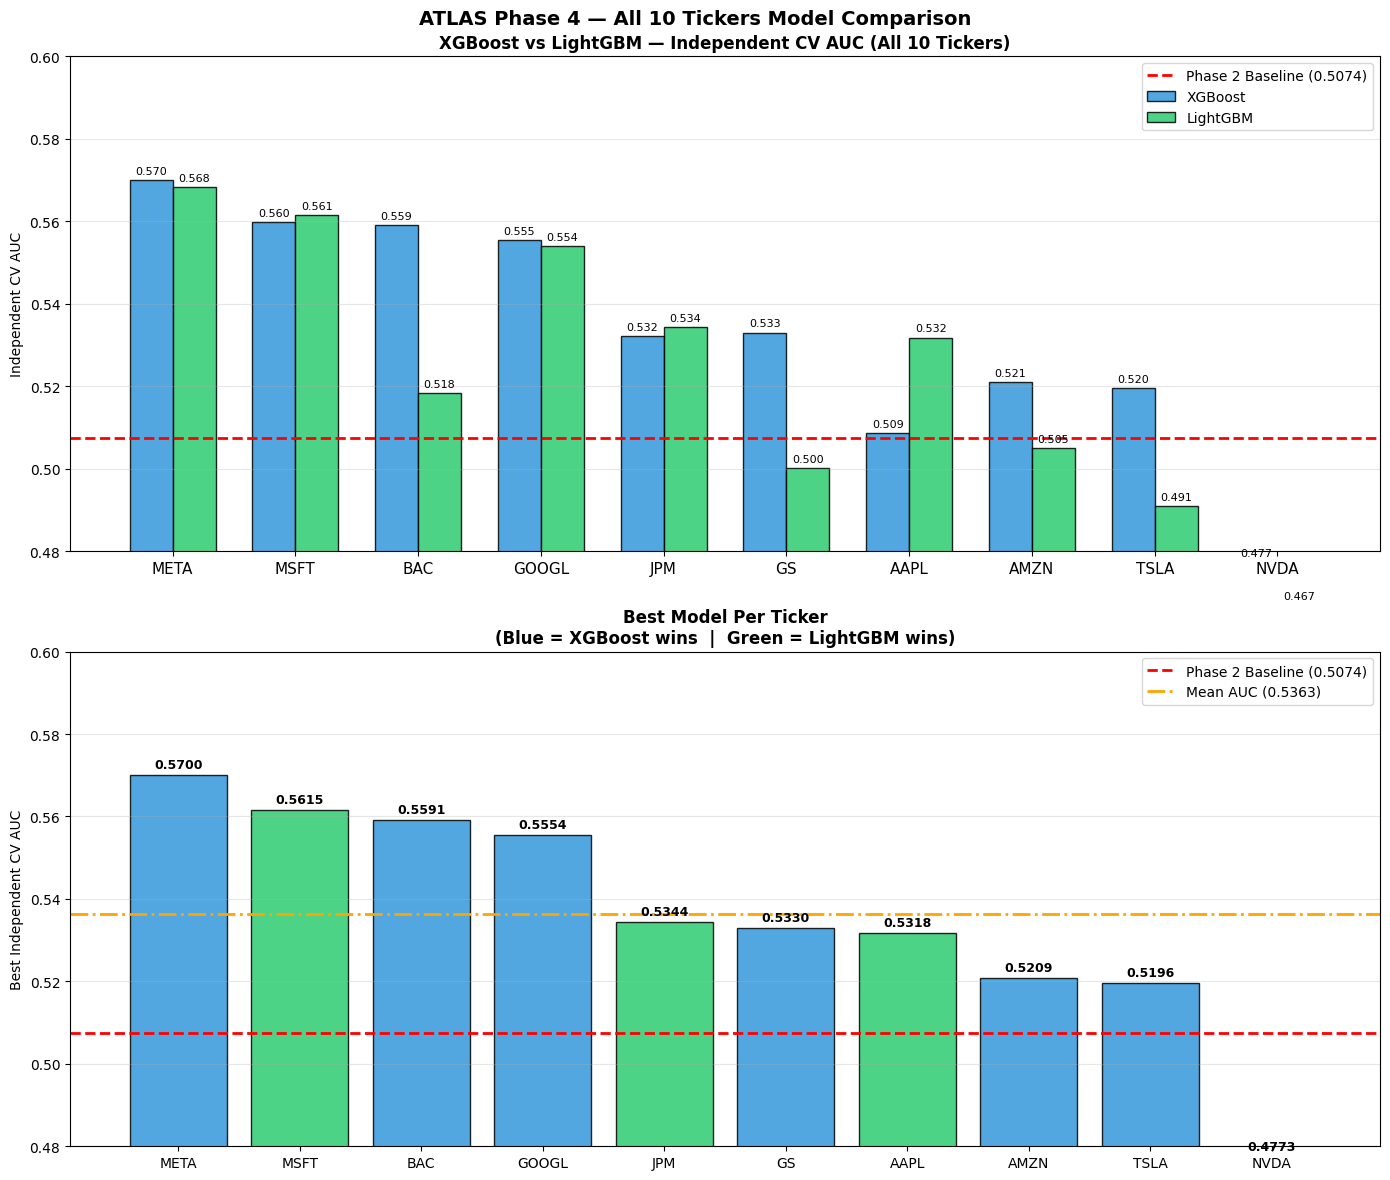

Best ticker:  META — AUC 0.5700
Worst ticker: NVDA — AUC 0.4773
Mean AUC:     0.5363
LightGBM wins: ['MSFT', 'JPM', 'AAPL']
XGBoost wins:  ['META', 'BAC', 'GOOGL', 'GS', 'AMZN', 'TSLA', 'NVDA']
Chart saved to docs/all_tickers_comparison.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load already saved CSV — no retraining needed
results_df = pd.read_csv('../../docs/all_tickers_results.csv')
results_sorted = results_df.sort_values('Best Independent CV', ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# ── Chart 1: XGBoost vs LightGBM side by side ───────────────
x     = range(len(results_sorted))
width = 0.35

bars1 = axes[0].bar(
    [i - width/2 for i in x],
    results_sorted['XGB Independent CV'],
    width, label='XGBoost', color='#3498DB',
    edgecolor='black', alpha=0.85
)
bars2 = axes[0].bar(
    [i + width/2 for i in x],
    results_sorted['LGBM Independent CV'],
    width, label='LightGBM', color='#2ECC71',
    edgecolor='black', alpha=0.85
)

axes[0].axhline(0.5074, color='red', linestyle='--',
                linewidth=2, label='Phase 2 Baseline (0.5074)')

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{bar.get_height():.3f}',
                 ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{bar.get_height():.3f}',
                 ha='center', va='bottom', fontsize=8)

axes[0].set_xticks(list(x))
axes[0].set_xticklabels(results_sorted['Ticker'], fontsize=11)
axes[0].set_title('XGBoost vs LightGBM — Independent CV AUC (All 10 Tickers)',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Independent CV AUC')
axes[0].set_ylim(0.48, 0.60)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')

# ── Chart 2: Best model per ticker ───────────────────────────
colors = ['#2ECC71' if w == 'LightGBM' else '#3498DB'
          for w in results_sorted['Winner']]

bars3 = axes[1].bar(
    results_sorted['Ticker'],
    results_sorted['Best Independent CV'],
    color=colors, edgecolor='black', alpha=0.85
)

for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{bar.get_height():.4f}',
                 ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

mean_auc = results_sorted['Best Independent CV'].mean()
axes[1].axhline(0.5074, color='red', linestyle='--',
                linewidth=2, label='Phase 2 Baseline (0.5074)')
axes[1].axhline(mean_auc, color='orange', linestyle='-.',
                linewidth=2, label=f'Mean AUC ({mean_auc:.4f})')

axes[1].set_title('Best Model Per Ticker\n'
                   '(Blue = XGBoost wins  |  Green = LightGBM wins)',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Best Independent CV AUC')
axes[1].set_ylim(0.48, 0.60)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('ATLAS Phase 4 — All 10 Tickers Model Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../../docs/all_tickers_comparison.png', dpi=150,
            bbox_inches='tight')
plt.show()

print(f'Best ticker:  {results_sorted.iloc[0]["Ticker"]} '
      f'— AUC {results_sorted.iloc[0]["Best Independent CV"]:.4f}')
print(f'Worst ticker: {results_sorted.iloc[-1]["Ticker"]} '
      f'— AUC {results_sorted.iloc[-1]["Best Independent CV"]:.4f}')
print(f'Mean AUC:     {mean_auc:.4f}')
print(f'LightGBM wins: {results_sorted[results_sorted["Winner"]=="LightGBM"]["Ticker"].tolist()}')
print(f'XGBoost wins:  {results_sorted[results_sorted["Winner"]=="XGBoost"]["Ticker"].tolist()}')
print('Chart saved to docs/all_tickers_comparison.png')